<a href="https://colab.research.google.com/github/Glockrover/LearnTensorFlow/blob/main/Neural_Network_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Classification with Neural network in TensorFlow

In this notebook we're are going to learn how to write a neural network for classification problems.

A classificationis where you try to classify something as one thing or another.

A few types of classifaction problems:

* Binary classification
* Multiclass classification
* Multilabel classification

## Creating day to view and fit

In [1]:
from sklearn.datasets import make_circles

# Make 1000 examples

n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)



In [2]:
# Check out features anf labels
X[:3], y[:3]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203]]),
 array([1, 1, 1]))

Our data is a little hard to understand right now... let's visualize it!

In [3]:
import pandas as pd
circles = pd.DataFrame({"X0":X[:, 0], "X1":X[:, 1], "label":y})
circles

,X0,X1,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


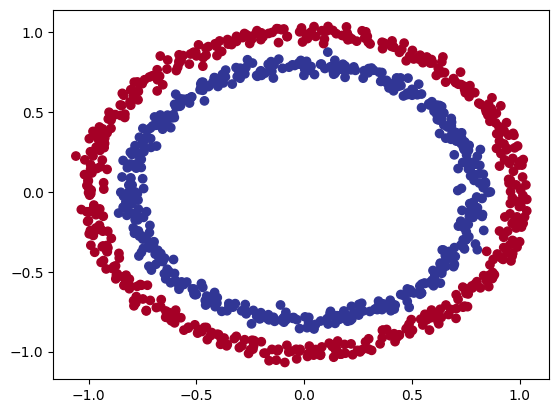

In [4]:
# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:,1], c=y, cmap=plt.cm.RdYlBu)

**Exercise:** Before pushing forward, spend 10 minutes playing arond with [playgrouund.tensorflow.org](https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.84405&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false) building and running differernt neural networks. See what happens when you change different hyperparameters.

## Input and out shapes

In [5]:
# Check the shape of our features and labels
X.shape, y.shape

((1000, 2), (1000,))

In [6]:
# How many samples we're working with
len(X), len(y)

(1000, 1000)

In [7]:
# View the first example of features and labels
X[0], y[0]

(array([0.75424625, 0.23148074]), np.int64(1))

## Steps in modelling

The steps in modelling with TensorFlow are typically:

1. Create or import a model
2. Compile the model
3. Fit the model
4. Evaluate the model
5. Tweak
6. Evaluate...

In [8]:
import tensorflow as tf

# Set the random seed
tf.random.set_seed(42)

def create_model():
  # 1. Create the model using the Sequential APi
  model = tf.keras.Sequential([
      tf.keras.layers.Dense(1)
  ])

  # 2. Compile the model
  model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["accuracy"])
  return model

# Creating our model
model1 = create_model()

# 3. Fit the model
model1.fit(X,y,epochs=100)


Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4990 - loss: 2.5837
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5220 - loss: 0.7119
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5040 - loss: 0.6987
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5020 - loss: 0.6958
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4940 - loss: 0.6948
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4890 - loss: 0.6945
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4750 - loss: 0.6944
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4680 - loss: 0.6944
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4540 - loss: 0.6944
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4550 - loss: 0.6944
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4470 - loss: 0.6944
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy:

In [9]:
# Let's try and improve our model
model1.fit(X,y, epochs=200, verbose=0)

# 4. Evaluate our mode
model1.evaluate(X,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4730 - loss: 0.6933


[0.6932879686355591, 0.4729999899864197]

Since we're working on a binary classification problem and our model is getting around ~47% accuracy... it's peforming as if it's guessing.

So let's step thing up a notch and add an extra layer.

In [10]:
# Set the random seed
tf.random.set_seed(42)

def create_model():
  # 1. Create the model with 2 layers
  model = tf.keras.Sequential([
      tf.keras.layers.Dense(1),
      tf.keras.layers.Dense(1)
  ])

  # 2. Compile the model
  model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["accuracy"])
  return model

# Creating our model
model2 = create_model()

# 3. Fit the model
model2.fit(X,y,epochs=100, verbose=0)


In [11]:
model2.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4670 - loss: 0.6934


[0.6934226751327515, 0.46700000762939453]

In [12]:
circles["label"].value_counts()

,count
label,
1,500
0,500


## Improving our model

Let's look into our bag of trick to see how we can improve our model.

1. Create a model - we might add more layers or increase the number of hidden units within a layer.
2. Compilling a model - here we might want to choose a different optimazation function as Adam instead of SGD.
3. Fitting a model - perhaps we might fit our model for more epochs (leave it traing for longer )

In [13]:
def create_model():
  # 1. Create the model using the Sequential APi
  model = tf.keras.Sequential([
      tf.keras.layers.Dense(100),
      tf.keras.layers.Dense(10),
      tf.keras.layers.Dense(1),
  ])

  # 2. Compile the model
  model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])
  return model

# Creating our model
model3 = create_model()

# 3. Fit the model
model3.fit(X,y,epochs=100, verbose=0)


In [14]:
# 4. Evaluate the model
model3.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4850 - loss: 0.6952


[0.69517982006073, 0.48500001430511475]

In [15]:
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 100)            │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,965 (15.49 KB)

 Trainable params: 1,321 (5.16 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,644 (10.33 KB)

To visualize our model's predictions, let's create a function `plot_decision_boundary` This function will:

* Take in a trained model, feature (X) and labels (y)
* Create a meshgrid o fhte differnret feature values
* Make predictions across the mesh
* Plot decision boundary

In [17]:
import numpy as np

def plot_decision_boundary(model, X, y):
  """
  Plots the decision boundary created by a model predicting X and y labels
  """

  # Defind the axis boundaries of the plot and create a meshgrid
  x_min, x_max = X[:, 0].min() - min(X[:, 0]), X[:, 0].max() + max(X[:, 0])
  y_min, y_max = X[:, 1].min() - min(X[:, 1]), X[:, 1].max() + max(X[:, 1])

  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                       np.linspace(y_min, y_max, 100))

  # Create X values (we're going to make predictions on these)
  x_in = np.c_[xx.ravel(), yy.ravel()] # stack 2D arrays together

  # Make predictions
  y_pred = model.predict(x_in)

  # Check for multi-class
  if len(y_pred[0]) > 1:
    print("doing multiclass classification")
    # We have to reshape our predictions
    y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
  else:
    print("doing binary classification")
    y_pred = np.round(y_pred).reshape(xx.shape)

  # Plot the decisionn boundary
  plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
  plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
doing binary classification


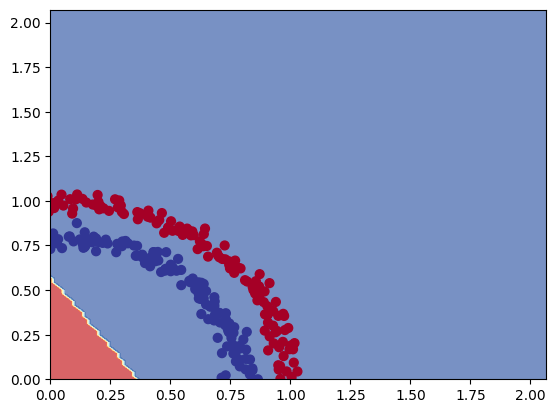

In [18]:
# Check out the predictions our model is making
plot_decision_boundary(model3, X, y)